In [2]:
from sklearn.model_selection import train_test_split
from lazypredict.Supervised import LazyClassifier
import pandas as pd
import sys

In [3]:
# Read CSV files
sailing = pd.read_csv("sailing_hourly_aligned.csv")
lake = pd.read_csv("ith_2015_2025_winter_with_lake_effect.csv")

# Clean names
sailing.columns = sailing.columns.str.strip()
lake.columns = lake.columns.str.strip()

# Rename columns in sailing dataset to match common weather variable names
sailing = sailing.rename(columns={
    "Air Temp": "tmpf",
    "Relative Humidity (%)": "relh",
    "Wind Speed (mph)": "sknt",
    "Wind Direction (degrees)": "drct",
    "Precipitation (inches)": "p01i",
    "Solar Radiation (langleys)": "solar_rad"
})

# Convert date columns to datetime and floor to the nearest hour
sailing["date"] = pd.to_datetime(sailing["date"], errors="coerce").dt.floor("h")
lake["valid"] = pd.to_datetime(lake["valid"], errors="coerce").dt.floor("h")
lake_label = lake[["valid", "lake_effect_flag"]].copy()

#Merge datasets on the date column
merged = pd.merge(
    sailing,
    lake_label,
    left_on="date",
    right_on="valid",
    how="inner"
)
merged = merged.drop(columns=["valid"])

print("merged shape:", merged.shape)
print(merged.head())
print(merged.columns)

merged shape: (731, 8)
                 date  tmpf  p01i  relh  solar_rad  sknt  drct  \
0 2025-01-01 00:00:00  42.0  0.04    87          0   6.6   126   
1 2025-01-01 01:00:00  41.4  0.07    91          0   5.7   133   
2 2025-01-01 02:00:00  41.5  0.06    89          0   4.6   124   
3 2025-01-01 03:00:00  41.1  0.00    90          0   0.8   189   
4 2025-01-01 04:00:00  40.6  0.00    91          0   1.7   191   

   lake_effect_flag  
0                 0  
1                 0  
2                 0  
3                 0  
4                 0  
Index(['date', 'tmpf', 'p01i', 'relh', 'solar_rad', 'sknt', 'drct',
       'lake_effect_flag'],
      dtype='object')


/var/folders/z3/k31cpzzj2q92203dt75gc8wr0000gn/T/ipykernel_6378/2826801321.py:20: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  sailing["date"] = pd.to_datetime(sailing["date"], errors="coerce").dt.floor("h")


In [4]:
features = ["tmpf", "p01i", "relh", "solar_rad", "sknt", "drct"]
target = "lake_effect_flag"

for col in features + [target]:
    merged[col] = pd.to_numeric(merged[col], errors="coerce")

In [5]:
#Point biserial correlation 
from scipy.stats import pointbiserialr

results = {}
for col in features:
    valid = merged[[col, target]].dropna()
    corr, p = pointbiserialr(valid[target], valid[col])
    results[col] = (corr, p)

correlation_results = pd.DataFrame.from_dict(results, orient="index", columns=["Correlation", "P-value"])
correlation_results.sort_values("Correlation", ascending=False, inplace=True)

# Interpretation:
# Positive correlation → higher values associated with lake effect
# Negative correlation → lower values associated with lake effect
correlation_results

,Correlation,P-value
sknt,0.632883,4.587590e-83
drct,0.322600,3.635916e-19
relh,0.184006,5.463083e-07
p01i,-0.021404,5.634072e-01
solar_rad,-0.114160,1.992287e-03
tmpf,-0.252774,4.048166e-12


In [ ]:
# Spearman Rank Correlation
# Use if relationships are nonlinear or variables contain outliers.

spearman_corr = merged[features + [target]].corr(method="spearman")
spearman_corr[target].sort_values(ascending=False)

spearman_corr

,tmpf,p01i,relh,solar_rad,sknt,drct,lake_effect_flag
tmpf,1.000000,0.171855,0.215754,0.108716,-0.068887,-0.123769,-0.349884
p01i,0.171855,1.000000,0.377481,0.073111,0.056493,0.002895,0.045497
relh,0.215754,0.377481,1.000000,-0.193867,-0.053486,0.214189,0.168701
solar_rad,0.108716,0.073111,-0.193867,1.000000,0.035125,0.066762,-0.062983
sknt,-0.068887,0.056493,-0.053486,0.035125,1.000000,0.453860,0.603821
drct,-0.123769,0.002895,0.214189,0.066762,0.453860,1.000000,0.404587
lake_effect_flag,-0.349884,0.045497,0.168701,-0.062983,0.603821,0.404587,1.000000


In [ ]:
# mutual Information
from sklearn.feature_selection import mutual_info_classif

X = merged[features].fillna(merged[features].median())
y = merged[target]
mutual_info = mutual_info_classif(X, y, discrete_features=False)
mutual_info_results = pd.Series(mutual_info, index=features).sort_values(ascending=False)
mutual_info_results


drct         0.302295
sknt         0.283771
tmpf         0.261097
relh         0.068892
solar_rad    0.027588
p01i         0.000000
dtype: float64

In [ ]:
# group means
group_means = merged.groupby(target)[features].mean()
group_means

,tmpf,p01i,relh,solar_rad,sknt,drct
lake_effect_flag,,,,,,
0,23.143003,0.001945,72.848123,3.252560,8.958362,241.757679
1,18.008966,0.001586,77.751724,1.717241,18.505517,307.000000


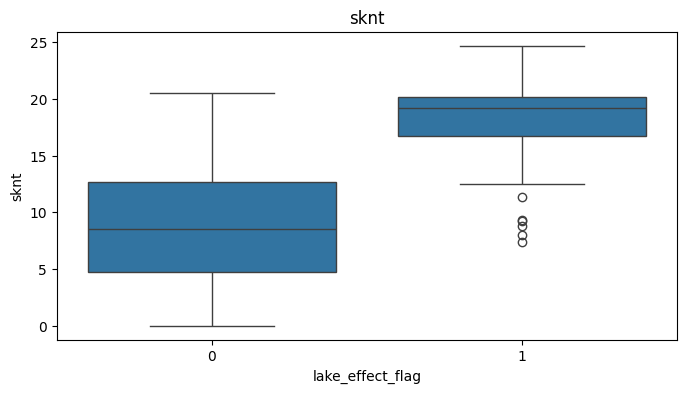

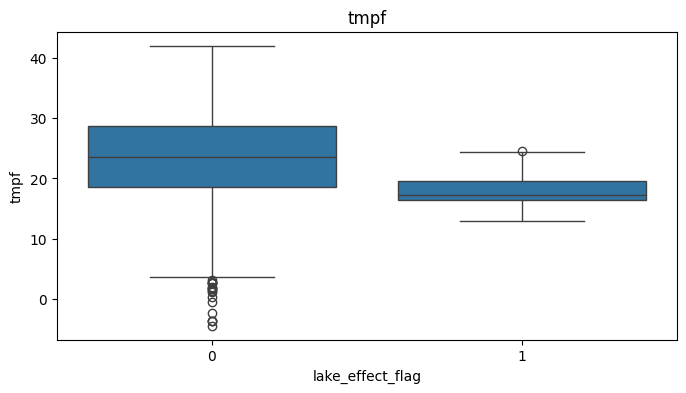

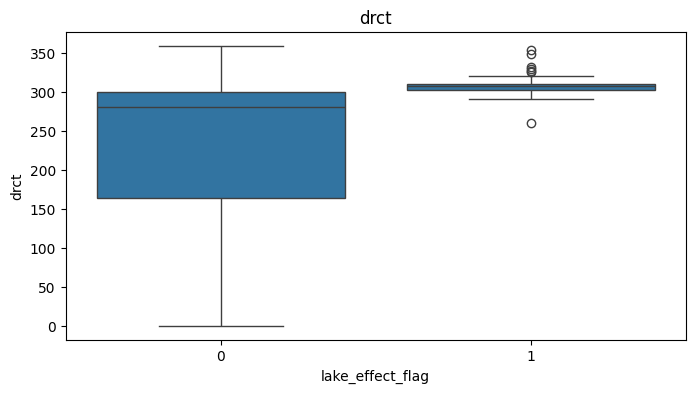

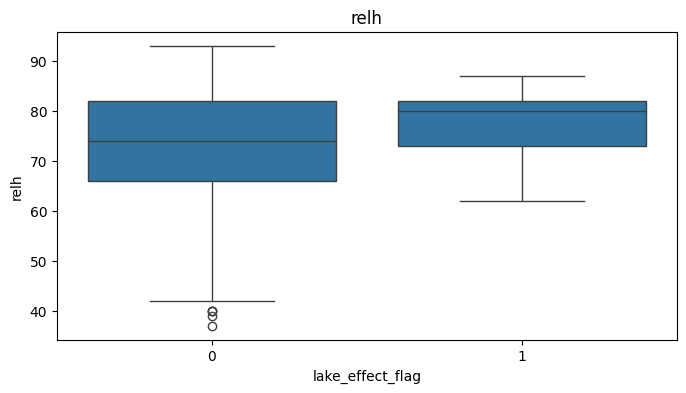

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt 

for col in ["sknt", "tmpf","drct","relh"]:
    plt.figure(figsize=(8, 4))
    sns.boxplot(data=merged, x=target, y=col)
    plt.title(col)
    plt.show()

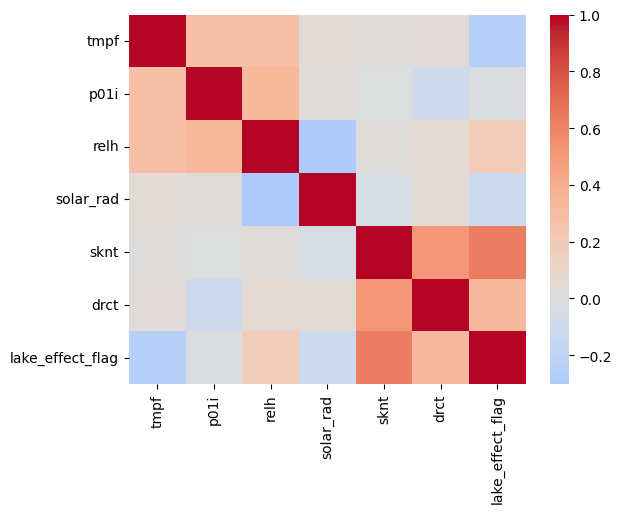

In [10]:
#  correlation heatmap
import seaborn as sns
import matplotlib.pyplot as plt

plain_corr = merged[features + [target]].corr(method="pearson")

sns.heatmap(plain_corr, cmap="coolwarm", center=0)
plt.show()

